# Exploration

## Initializations

In [1]:
# Remove the hash sign from the line below and run the cell to install the package for plotting
# !pip install git+https://github.com/garrettj403/SciencePlots

In [ ]:
# Imports from PET
from process_engineering_toolkit.units import ureg, standardize_units, Q_
from process_engineering_toolkit.stream import Stream
from process_engineering_toolkit.reactors.pfr import PFR
from process_engineering_toolkit.reactors.cstr import CSTR
from process_engineering_toolkit.rate_laws import MassActionRateLaw, PowerLawRateLaw
from process_engineering_toolkit.reactions import Reactions

# Plotting
import matplotlib.pyplot as plt
import scienceplots
from process_engineering_toolkit.visualization.reactor_plotter import ReactorPlotter

# Location for saved images
location = "../docs/images"

# Define units
Pa = ureg.Pa
atm = ureg.atm
mol = ureg.mole
J = ureg.joule
K = ureg.kelvin
L = ureg.liter
s = ureg.s
min = ureg.minute
dm = ureg.decimeter
m = ureg.meter

## README clean

### Example: Single-reaction system, (gas, PFR)

This example demonstrates how to define, reactions, streams, as well as plug flow reactor and how to simulate.

In [4]:
# -----------------------------
# 1. Define reactions
# -----------------------------
# Currently, two options are available.
# 1) Don't specify units: In this case the toolkit computes everything as is - The user will have to ensure unit consistency.
# 2) Specify units: The toolkit will convert to SI units internally, but the user can work with more intuitive units.
# Note: If using option 2, the user currently still has to provide rate constants/parameters in SI units. 
# The function standardize_units, which converts to desired units (and then strips them),
# can be used as below. 
kf = 0.3 / min              # Forward rate constant
kb = 3 * L / min / mol      # Backward rate constant
kf = standardize_units(kf, 1 / s)           # Convert to SI units and strip units
kb = standardize_units(kb, m**3 / s / mol)  # Convert to SI units and strip units

reactions = [
    {"equation": "A <-> 2B", "rate_law": "mass_action", "parameters": {"kf": kf, "kb": kb}}
    ]

rxns = Reactions(reactions)

# -----------------------------
# 2. Define inlet stream
# -----------------------------
s1 = Stream("Inlet1", total_flow = 20 * mol / min, composition = {"A": 0.6, "I": 0.4}) # I: Inert

# -----------------------------
# 3. Define reactor conditions
# -----------------------------
parameters = {
    "phase": "gas",       # Gas or liquid
    "T": 340 * K,         # Kelvin
    "P": 2 * 101325 * Pa  # Pascal
}

# -----------------------------
# 4. Instantiate reactor
# -----------------------------
pfr = PFR(rxns, inlet_streams=s1, parameters=parameters)

# -----------------------------
# 5. Key calculations
# -----------------------------
# Equilibrium conversion of A
Xeq = pfr.equilibrium_conversion("A")
print(f"{'Equilibrium conversion':<45}: {Xeq:.3f}")

# Solve reactor over volume range [0, 5] m3
pfr.solve(V_span=(0, 5))  # m3 - Must solve reactor before below calculations can be performed

# Conversion at specific volume
X = pfr.conversion_at_volume("A", 0.5)
print(f"{'Conversion at 0.5 m3':<45}: {X:.3f}")

# Required volume for target conversion
V_req = pfr.volume_for_conversion("A", 0.4)
print(f"{'Required PFR volume for 40% conversion, m3':<45}: {V_req:.3f}")

Equilibrium conversion                       : 0.576
Conversion at 0.5 m3                         : 0.351
Required PFR volume for 40% conversion, m3   : 0.632


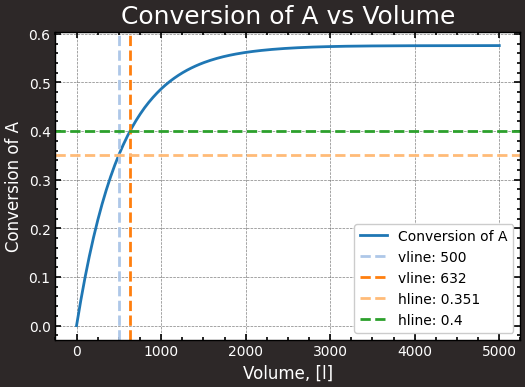

In [5]:
# Extract profiles
profile = pfr.profile(species_for_conversion="A") # The limiting reactant should be chosen as species for conversion.

# The ReactorPlotter can be used to visualize the conversion profile and add vertical/horizontal lines to indicate key values,
# such as the required volume for a target conversion or the equilibrium conversion.
plotter = ReactorPlotter()

# Specify filename for saved plot (without .png extension)
# filename = "conversion_vs_volume"

# Plot the figure
plotter.plot(profile, "volume", "conversion", legend_loc='best', vlines=[0.5*1000, V_req*1000], hlines=[X, 0.4], x_unit="L")

# If user wants to retain full control of the figure (e.g., to change title, axis labels, etc.).
# fig, ax = plotter.plot(profile, "volume", "conversion", legend_loc='best', vlines=[0.5*1000, V_req*1000], hlines=[X, 0.4], x_unit="L", save=True, filename=filename, location=location, finalize=True)
# ax.set_title("Custom title")
# ax.set_ylabel("Custom y-label")
# plt.show()
# plt.close()


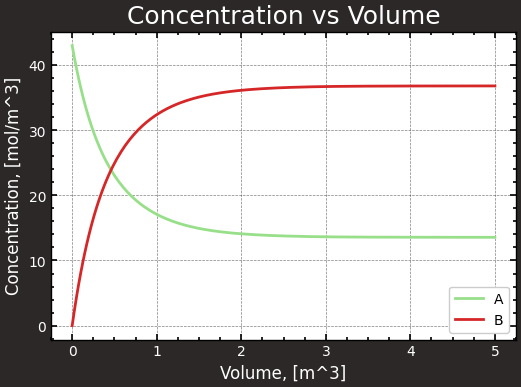

In [6]:
filename = "concentration_vs_volume"

# Excluding y_species will plot concentration profiles of all species in the reactor.
plotter.plot(profile, "volume", "concentration", y_species=["A", "B"])
# plotter.plot(profile, "volume", "concentration", y_species=["A", "B"], save=True, filename=filename, location=location)

### Example: Multi-reaction system, (liquid, PFR)

This example demonstrates how to define and simulate a plug flow reactor with:
- multiple simultaneous reactions
- different kinetic models (mass-action and custom power-law)
- multiple inlet streams

Equilibrium conversion                       : 0.474
Conversion at 0.5 m3                         : 0.361
Required PFR volume for 40% conversion, m3   : 0.601


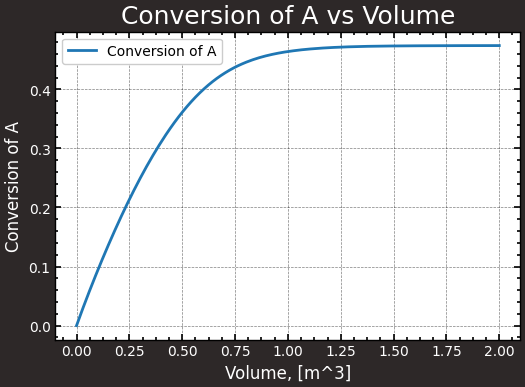

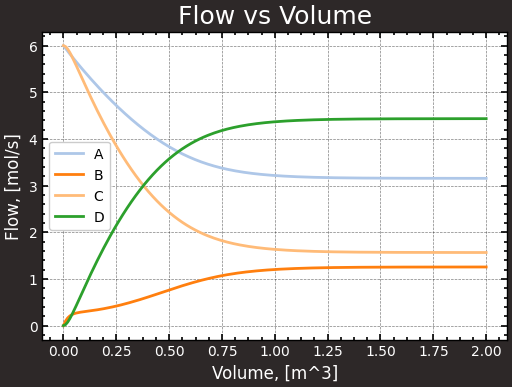

In [ ]:
# -----------------------------
# 1. Define reactions
# -----------------------------
# Rate parameters
kf2 = 10 * L / (mol * min)
kb2 = 1 * L / (mol * min)
kf2 = standardize_units(kf2, m**3 / (mol * s))  # Convert to SI units and strip units
kb2 = standardize_units(kb2, m**3 / (mol * s))     # Convert to SI units and strip units

# Custom power-law expression for B + C <-> D
# It should be noted that kf and kb in power law rate expressions are only allowed for the intuition's sake. 
# kf and kb are stripped under the hood and don't make an actual difference - Thus, you can also choose to leave them out. 
power_expr = "B * C - D^2"

reactions = [
    {"equation": "A <-> 2B",    "rate_law": "mass_action",  "parameters": {"kf": kf, "kb": kb}},
    {"equation": "B + C <-> D", "rate_law": "power",        "parameters": {"expression": power_expr, "kf": kf2, "kb": kb2}}
    ]

rxns = Reactions(reactions)

# -----------------------------
# 2. Define inlet stream
# -----------------------------
# Two independent feeds containing different reactants
s1 = Stream("Inlet1", total_flow=10, composition={"A": 0.6, "I": 0.4}) # I = inert
s2 = Stream("Inlet2", total_flow=10, composition={"C": 0.6, "I": 0.4}) # I = inert

# -----------------------------
# 3. Define reactor conditions
# -----------------------------
# Note: For liquid phase reactions, the user should specify volumetric flow (v0) instead of T and P.
# Note: Physical consistency between inlet streams and volumetric flow of reactors is not currently enforced.
#       This will be adressed in an upcoming update.
parameters = {
    "phase": "liquid",    # Gas or liquid
    "v0": 0.005 # m3/s.
}

# -----------------------------
# 4. Instantiate reactor
# -----------------------------
pfr = PFR(rxns, inlet_streams=[s1, s2], parameters=parameters)

# -----------------------------
# 5. Key calculations
# -----------------------------
# An initial guess can be provided if the solver in .equilibrium_conversion has trouble converging. 
# The initial guess should be provided as a dictionary with species as keys and flows as values.
# If a species is left out, the inlet flow will be used as initial guess for that species (nice for inerts).
# initial_guess = {"A": 3, "B": 1, "C": 2, "D": 4} # TIP: Solve the reactor with a V_span as below and use the final flows as initial guess
Xeq = pfr.equilibrium_conversion("A") # initial_guess=initial_guess
print(f"{'Equilibrium conversion':<45}: {Xeq:.3f}")

# Solve reactor over volume range [0, 2] m3
pfr.solve(V_span=(0, 2))  # m3 - Must solve reactor before below calculations can be performed

# Conversion at specific volume
X = pfr.conversion_at_volume("A", 0.5)
print(f"{'Conversion at 0.5 m3':<45}: {X:.3f}")

# Required volume for target conversion
V_req = pfr.volume_for_conversion("A", 0.4)
print(f"{'Required PFR volume for 40% conversion, m3':<45}: {V_req:.3f}")

profile = pfr.profile(species_for_conversion="A") # The limiting reactant should be chosen as species for conversion.
plotter = ReactorPlotter()
plotter.plot(profile, "volume", "conversion", legend_loc='best', y_species=["A", "B", "C", "D"])
plotter.plot(profile, "volume", "flow", legend_loc='best', y_species=["A", "B", "C", "D"])

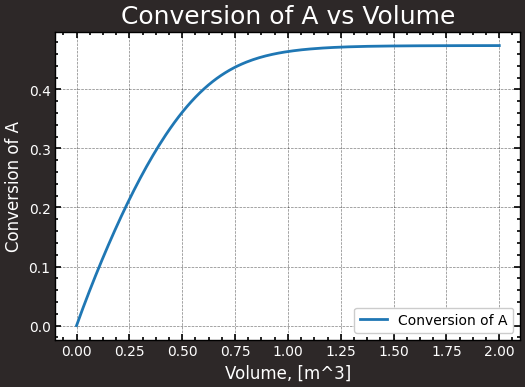

In [ ]:
# Extract profiles
profile = pfr.profile(species_for_conversion="A") # The limiting reactant should be chosen as species for conversion.
# Instantiate plotter
plotter = ReactorPlotter()


plotter.plot(profile, "volume", "conversion")

# Plot and save the figure
# plotter.plot(profile, "volume", "conversion", save=True, filename="conversion_vs_volume_multi", location=location)

# fig, ax = plotter.plot(profile, "volume", "conversion", finalize=False)
# ax.set_title("Custom title")
# ax.set_ylabel("Custom y-label")
# plt.show()
# plt.close()

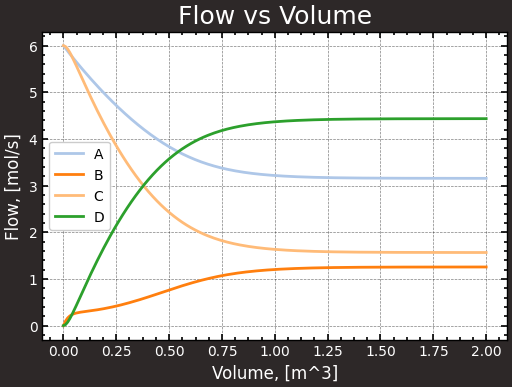

In [ ]:
### Flow of all species vs volume

# Specify filename for saved plot (without extension)
filename = "flow_vs_volume_multi"

# Plot the figure
plotter.plot(profile, "volume", "flow", legend_loc='best', y_species=["A", "B", "C", "D"], save=True, filename=filename, location=location)

# fig, ax = plotter.plot(profile, "volume", "conversion", legend_loc='best', vlines=[0.5*1000, V_req*1000], hlines=[X, 0.4], x_unit="L", save=True, filename=filename, location=location, finalize=True)
# ax.set_title("Custom title")
# ax.set_ylabel("Custom y-label")
# plt.show()
# plt.close()

### Example: Multi-reaction system, (liquid, irreversible, CSTR)

In [ ]:
k1 = 0.01 * m**3 / mol / s
k2 = 0.001 / s
k1 = standardize_units(k1, m**3 / mol / s)           # Convert to SI units and strip units
k2 = standardize_units(k2, 1 / s)  # Convert to SI units and strip units

# -----------------------------
# 1. Define reactions
# -----------------------------
reactions = [
    {"equation": "A + B -> C", "rate_law": "mass_action",  "parameters": {"kf": k1}},
    {"equation": "A -> 2D",    "rate_law": "mass_action",  "parameters": {"kf": k2}}
    ]

rxns = Reactions(reactions)

# -----------------------------
# 2. Define inlet stream
# -----------------------------
# Determine molar flow from v = 0.005 m3/s and CA0 = CB0 = 0.1 mol/m3
CA0 = CB0 = 0.1 * mol / m**3
molar_flow = 0.005 * m**3 / s * CA0  # mol/s

# Two independent feeds containing different reactants
s = Stream("Inlet1", total_flow=molar_flow*2, composition={"A": 0.5, "B": 0.5})

# -----------------------------
# 3. Define reactor conditions
# -----------------------------
parameters = {
    "phase": "liquid",
    "v0": 0.005 # m3/s
}

# -----------------------------
# 4. Instantiate reactor
# -----------------------------
cstr = CSTR(rxns, inlet_streams=s, parameters=parameters)

# -----------------------------
# 5. Key calculations
# -----------------------------
# Equilibrium conversion of A
Xeq = cstr.equilibrium_conversion("A")
print(f"{'Equilibrium conversion':<45}: {Xeq:.3f}")

# Solve reactor over volume range [0, 10] m3
cstr.solve(V=(0, 5))  # m3 - Must solve reactor before below calculations can be performed

# Conversion at specific volume
X = cstr.conversion_at_volume("A", 5)
print(f"{'Conversion at 5 m3':<45}: {X:.3f}")

# Required volume for target conversion
V_req = cstr.volume_for_conversion("A", 0.4)
print(f"{'Required CSTR volume for 40% conversion, m3':<45}: {V_req:.3f}")

Equilibrium conversion                       : 1.000
Conversion at 5 m3                           : 0.634
Required CSTR volume for 40% conversion, m3  : 1.832


In [14]:
print(0.2679+0.3660)

0.6339


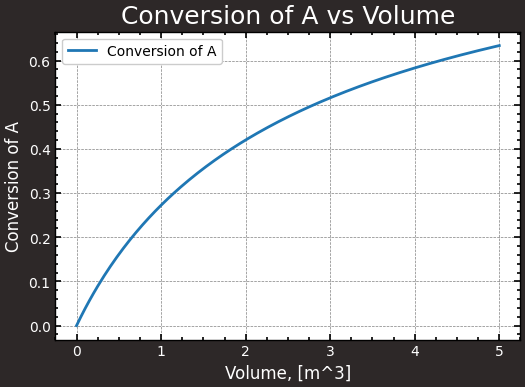

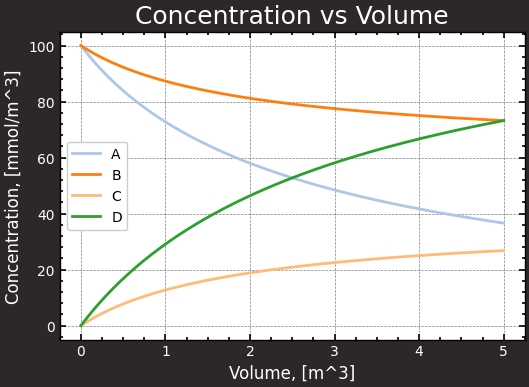

In [17]:
cstr_plotter = ReactorPlotter()
cstr_profile = cstr.profile(species_for_conversion="A")
cstr_plotter.plot(cstr_profile, "volume", "conversion", legend_loc='best', save=True, filename="conversion_vs_volume_multi_cstr", location=location)
cstr_plotter.plot(cstr_profile, "volume", "concentration", legend_loc='best', y_unit="mmol/m^3", save=True, filename="concentration_vs_volume_multi_cstr", location=location)

## Mass Action vs Power Law testing

### Setup

In [ ]:
import numpy as np
from process_engineering_toolkit.reactions import Reaction
from process_engineering_toolkit.rate_laws import MassActionRateLaw, PowerLawRateLaw

# Species
species_list = ["A", "B", "C"]
species_index = {s: i for i, s in enumerate(species_list)}

# Stoichiometry
stoichiometry = {
    "A": -1,
    "B": -1,
    "C": 1
}

# Concentrations (mol/L)
C = np.array([2.0, 1.5, 0.0])
T = 350  # K

Mass action rate: 1.5
species_list: ['A', 'B', 'C']
species_index: {'A': 0, 'B': 1, 'C': 2}


### Rate determination: Irreversibel reaction

In [13]:
# Mass Action (elementary reaction)
params_mass_action = {
    "kf": 0.5
}

ma = MassActionRateLaw(stoichiometry, **params_mass_action)

rxn = Reaction("R1", stoichiometry, ma)
rxn._compile(species_index)

print("Mass action rate:", rxn.rate(C, T))
print(f"species_list: {species_list}")
print(f"species_index: {species_index}")

Mass action rate: 1.5
species_list: ['A', 'B', 'C']
species_index: {'A': 0, 'B': 1, 'C': 2}


In [14]:
# Power Law
params_power_law = {
    "expression": "A * B",
    "kf": 0.5
}

pl = PowerLawRateLaw(stoichiometry, **params_power_law)

rxn = Reaction("R1", stoichiometry, pl)
rxn._compile(species_index)

print("Power law rate:", rxn.rate(C, T))
print(f"species_list: {species_list}")
print(f"species_index: {species_index}")

Power law rate: 1.5
species_list: ['A', 'B', 'C']
species_index: {'A': 0, 'B': 1, 'C': 2}


### Rate determination: Reversible reaction

In [15]:
C = np.array([2.0, 1.5, 0.5])
T = 350

In [16]:
# Mass Action (elementary reaction)
params_mass_action = {
    "kf": 0.5,
    "kb": 0.1,
}

ma = MassActionRateLaw(stoichiometry, **params_mass_action)

rxn = Reaction("R1", stoichiometry, ma)
rxn._compile(species_index)

print("Mass action rate:", rxn.rate(C, T))
print(f"species_list: {species_list}")
print(f"species_index: {species_index}")

Mass action rate: 1.45
species_list: ['A', 'B', 'C']
species_index: {'A': 0, 'B': 1, 'C': 2}


In [19]:
# Power law
params_mass_action = {
    "expression": "A * B - C",
    "kf": 0.5,
    "kb": 0.1,
}

pl = PowerLawRateLaw(stoichiometry, **params_mass_action)

rxn = Reaction("R1", stoichiometry, pl)
rxn._compile(species_index)

print("Power Law rate:", rxn.rate(C, T))
print(f"species_list: {species_list}")
print(f"species_index: {species_index}")

Power Law rate: 1.45
species_list: ['A', 'B', 'C']
species_index: {'A': 0, 'B': 1, 'C': 2}


### Non-integer orders (Power Law only)

In [25]:
params_power_law = {
    "expression": "A^0.5 * B^1.2 - C^1.5",
    "kf": 0.5,
    "kb": 0.1,
}

pl = PowerLawRateLaw(stoichiometry, **params_power_law)

rxn = Reaction("R1", stoichiometry, pl)
rxn._compile(species_index)

print("Power Law rate:", rxn.rate(C, T))
print(f"species_list: {species_list}")
print(f"species_index: {species_index}")

Power Law rate: 1.1149006760695908
species_list: ['A', 'B', 'C']
species_index: {'A': 0, 'B': 1, 'C': 2}


In [26]:
print(0.5*C[0]**(0.5)*C[1]**(1.2) - 0.1*C[2]**1.5)

1.1149006760695908


### Arrhenius test

In [ ]:
params_mass_action = {
    "k0_f": 1e3,
    "Ea_f": 50000  # J/mol
}

ma = MassActionRateLaw(stoichiometry, species_list, **params_mass_action)

print("Mass action Arrhenius rate:", ma.rate(C, T))

Mass action Arrhenius rate: 3.448570123742299e-05


In [10]:
for T in [300, 350, 400]:
    print(T, ma.rate(C, T))

300 5.902465985837268e-06
350 0.00010345710371226898
400 0.0008862483374188033


In [11]:
params_power_law = {
    "expression": "A * B",
    "k0_f": 1e3,
    "Ea_f": 50000  # J/mol
}

pl = PowerLawRateLaw(stoichiometry, species_list, **params_power_law)

print("Power law Arrhenius rate:", pl.rate(C, 350))

Power law Arrhenius rate: 0.00010345710371226898


In [12]:
for T in [300, 350, 400]:
    print(T, pl.rate(C, T))

300 5.902465985837268e-06
350 0.00010345710371226898
400 0.0008862483374188033


### Edge cases: Invalid usage

In [13]:
PowerLawRateLaw(
    stoichiometry,
    species_list,
    expression="A * B",
    kb=0.1  # ← should trigger validation
)

ValueError: Backward rate constants provided but expression has no backward term

In [14]:
PowerLawRateLaw(
    stoichiometry,
    species_list,
    expression="A * D",  # D not in species_list
    kf=1.0
)

ValueError: Unknown species in rate expression: D

In [23]:
PowerLawRateLaw(
    stoichiometry,
    species_list,
    expression="a**(1/2) * B",  # Invalid math symbol (for simplicity, division symbol not allowed)
    kf=1.0
)

ValueError: Invalid exponent in factor a^(1/2)

## Stream definition

In [ ]:
# # This will raise an error as mole fractions must be non-negative
# s1 = Stream("Fresh A", 10, {"A": -1, "B": 0.5}) 
# s2 = Stream("Co-feed", 5, {"B": 0.6, "C": 0.4})

# print(s1.flows)
# print(s2.flows)

# # This will raise an error as compositions must sum to 1
# s1 = Stream("Fresh A", 10, {"A": 0.7, "B": 0.2}) 
# s2 = Stream("Co-feed", 5, {"B": 0.6, "C": 0.4})

# print(s1.flows)
# print(s2.flows)

# inlet = Flow([s1, s2])
# print(inlet.total_flows())

# s1 = Stream("Fresh A", 10, {"A": 0.8, "B": 0.2})
# s2 = Stream("Co-feed", 5, {"B": 0.6, "C": 0.4})

# print(s1.flows)
# print(s2.flows)